In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
mnist = fetch_openml('mnist_784')
mnist_data = mnist.data[:10000]
mnist_target = mnist.target[:10000]
print(mnist_data)
print(mnist_data.shape)
print(mnist_target)
print(mnist_target.shape)

      pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0          0       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          0       0       0       0       0       0       0       0       0   
3          0       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
9995       0       0       0       0       0       0       0       0       0   
9996       0       0       0       0       0       0       0       0       0   
9997       0       0       0       0       0       0       0       0       0   
9998       0       0       0       0       0       0       0       0       0   
9999       0       0       0       0       0       0       0       0       0   

      pixel10  ...  pixel775  pixel776 

In [3]:
X_train,X_test,y_train,y_test=train_test_split(mnist.data,
mnist.target,
test_size=0.2)

In [4]:
dt_clf = tree.DecisionTreeClassifier()
rf_clf = RandomForestClassifier()
dt_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
accuracy_dt = accuracy_score(y_test, dt_pred)
accuracy_rf = accuracy_score(y_test, rf_pred)

In [5]:
print('의사결정 트리 예측 정확도: {0:.4f}'.format(accuracy_dt))
print('랜덤 포레스트 예측 정확도: {0:.4f}'.format(accuracy_rf))

의사결정 트리 예측 정확도: 0.8751
랜덤 포레스트 예측 정확도: 0.9692


In [6]:
print(rf_clf)

RandomForestClassifier()


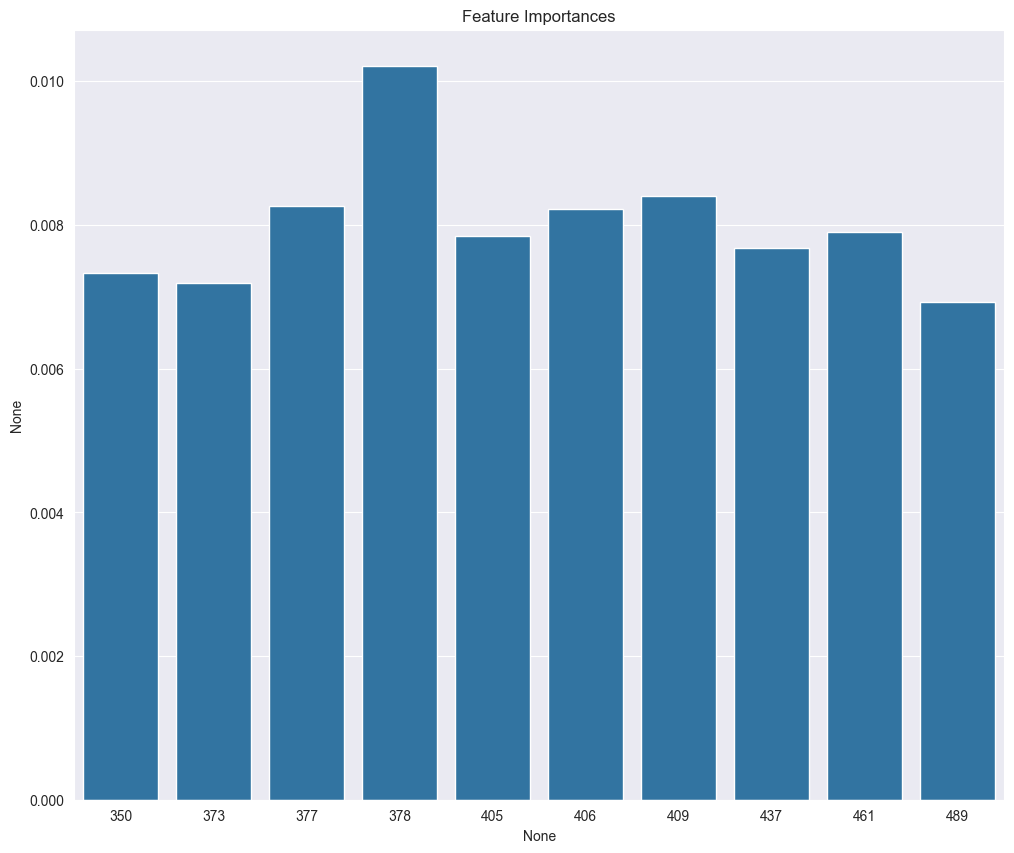

In [7]:
ft_importances_values = rf_clf.feature_importances_
ft_importances = pd.Series(ft_importances_values)
top10 = ft_importances.sort_values(ascending=False)[:10]
plt.figure(figsize=(12,10))
plt.title('Feature Importances')
sns.barplot(x=top10.index, y=top10)
plt.show()

In [12]:
rf_param_grid ={
'n_estimators' : [100, 110, 120],
'min_samples_leaf' : [1, 2, 3],
'min_samples_split' : [2, 3, 4]
}
rf_clf = RandomForestClassifier(random_state = 0, n_jobs=-1)
grid = GridSearchCV(rf_clf, param_grid = rf_param_grid,
scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/stenv/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/envs/stenv/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 180, in <module>
    exitcode = process_obj._bootstrap()
  File "/opt/anaconda3/envs/stenv/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
   

GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=0),
             n_jobs=-1,
             param_grid={'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [100, 110, 120]},
             scoring='accuracy')

In [13]:
print('최고 평균 정확도 : {0:.4f}'.format(grid.best_score_))
print(grid.best_params_)

최고 평균 정확도 : 0.9671
{'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 110}
